In [26]:
# === Cell 1 — Imports, paths, style, colors ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import ast

# Paths
DATA_DIR = Path('../data/processed')
OUTPUTS_DIR = Path('../outputs')
FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

# Brand colors — used consistently across ALL figures
ADZUNA_COLOR = '#1f77b4'    # tab:blue
JOBBANK_COLOR = '#ff7f0e'   # tab:orange
ANNOTATION_GRAY = '#555555' # for n= labels (subtle, not loud)

# Global style
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100        # inline display
plt.rcParams['savefig.dpi'] = 150       # PNG export quality
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['font.family'] = 'sans-serif'

# Display options for any DataFrames we peek at
pd.set_option('display.float_format', '{:,.0f}'.format)

print('✅ Setup ready')
print(f'   Figures will be saved to : {FIGURES_DIR.resolve()}')
print(f'   Adzuna  = {ADZUNA_COLOR}  (blue)')
print(f'   JobBank = {JOBBANK_COLOR}  (orange)')

✅ Setup ready
   Figures will be saved to : C:\Users\rebec\Documents\GitHub\toronto-data-job-market-analysis\outputs\figures
   Adzuna  = #1f77b4  (blue)
   JobBank = #ff7f0e  (orange)


In [27]:
# --- Session 6 aggregates

salary_role_adz = pd.read_csv(OUTPUTS_DIR/'salary_by_role_adzuna.csv')
salary_role_jb        = pd.read_csv(OUTPUTS_DIR / 'salary_by_role_jobbank.csv')
salary_region_adz     = pd.read_csv(OUTPUTS_DIR / 'salary_by_region_adzuna.csv')
salary_region_jb      = pd.read_csv(OUTPUTS_DIR / 'salary_by_region_jobbank.csv')
salary_skill_adz      = pd.read_csv(OUTPUTS_DIR / 'salary_by_skill_adzuna.csv')

# --- Raw datasets

adzuna_raw  = pd.read_csv(DATA_DIR / 'adzuna_jobs_with_skills.csv')
jobbank_raw = pd.read_csv(DATA_DIR / 'jobbank_ontario_data_clean.csv')

# --- Recreate salary_avg on Adzuna 
adzuna_raw['_salary_avg'] = (adzuna_raw['salary_min'] + adzuna_raw['salary_max']) / 2

# Filter Adzuna to salary-disclosed jobs only
adz = adzuna_raw[adzuna_raw['_salary_avg'].notna()].copy()

# Sanity checks — catch silent bugs 
assert len(adz) == 258, f'Expected 258 Adzuna salary-disclosed jobs, got {len(adz)}'
assert len(jobbank_raw) == 1111, f'Expected 1111 Job Bank jobs, got {len(jobbank_raw)}'

# Quick recap
print(' Aggregates loaded:')
print(f'   salary_role_adz      : {salary_role_adz.shape}')
print(f'   salary_role_jb       : {salary_role_jb.shape}')
print(f'   salary_region_adz    : {salary_region_adz.shape}')
print(f'   salary_region_jb     : {salary_region_jb.shape}')
print(f'   salary_skill_adz     : {salary_skill_adz.shape}')
print()
print(' Raw datasets loaded:')
print(f'   adz (Adzuna salary)  : {len(adz):,} jobs')
print(f'   jobbank_raw          : {len(jobbank_raw):,} jobs')
print()
print('All sanity checks passed')

jobbank_raw.columns.to_list()



 Aggregates loaded:
   salary_role_adz      : (5, 6)
   salary_role_jb       : (4, 7)
   salary_region_adz    : (10, 6)
   salary_region_jb     : (9, 6)
   salary_skill_adz     : (7, 6)

 Raw datasets loaded:
   adz (Adzuna salary)  : 258 jobs
   jobbank_raw          : 1,111 jobs

All sanity checks passed


['WIC Job Location Snapshot ID',
 'First Posting Date',
 '_noc21_clean',
 'Job Title',
 'NOC21 Code Name',
 'Province/Territory',
 'City',
 'Economic  Region',
 'Salary Minimum',
 'Salary Maximum',
 'Salary Per',
 '_salary_per_corrected',
 'salary_min_annual',
 'salary_max_annual',
 'salary_avg_annual',
 'Education LOS',
 'Experience Level',
 'Hours Minimum',
 'Hours Maximum',
 'Hours Per',
 '_source_month']

In [28]:
# ===  Quick diagnostic before plotting ===

print('🔍 Adzuna raw columns:')
print(adz.columns.tolist())
print()
print('🔍 salary_role_adz preview:')
print(salary_role_adz)
print()
print('🔍 salary_role_jb preview:')
print(salary_role_jb)

🔍 Adzuna raw columns:
['salary_max', 'latitude', 'redirect_url', 'title', 'created', 'salary_min', 'id', 'description', 'longitude', 'contract_time', '_search_query', 'company', 'category', 'category_tag', 'location', 'location_area', 'contract_type', 'city', 'week', 'day_of_week', 'is_recent', 'skills', 'text_to_search', '_salary_avg']

🔍 salary_role_adz preview:
      _search_query  count  median    mean    min     max
0   data consultant     35 137,500 141,785 52,500 232,000
1    data scientist     44 130,000 129,393 69,582 215,000
2     data engineer     47 120,000 124,577 55,120 270,750
3  business analyst     60  92,446 103,015 55,000 228,800
4      data analyst     68  89,938  93,452 46,800 209,500

🔍 salary_role_jb preview:
   _noc21_clean                            NOC21 Code Name  count  median  \
0         21211                            Data scientists    215 103,730   
1         21221               Business systems specialists    175  96,897   
2         21223  Database a

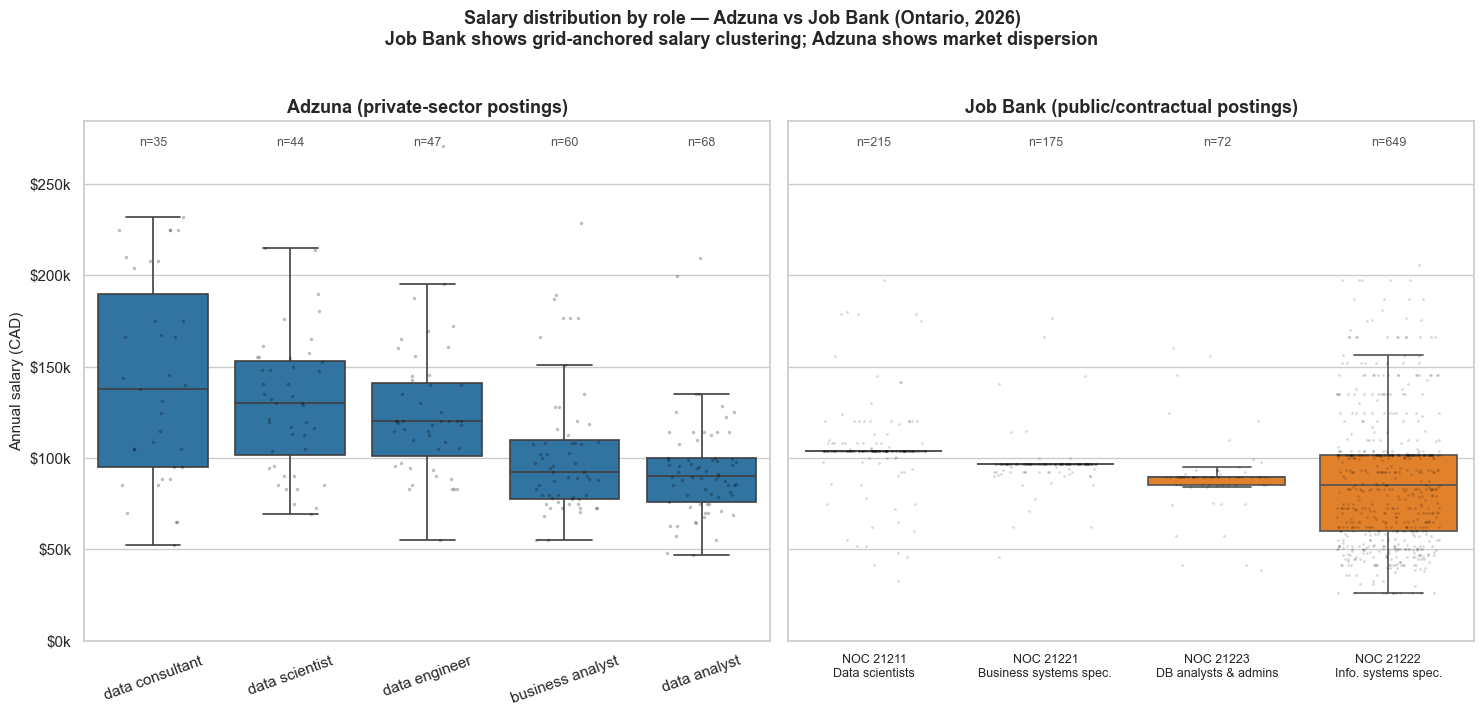

✅ Saved → ..\outputs\figures\salary_by_role_boxplot.png


In [29]:
# ===  boxplot: salary by role, Adzuna vs Job Bank ===

# - Publishable role

publishable_roles_adz = salary_role_adz['_search_query'].tolist()
publishable_roles_jb = salary_role_jb ['_noc21_clean'].tolist()

# Filter raw data to publishable role only

adz_plot = adz[adz['_search_query'].isin(publishable_roles_adz)].copy()
jb_plot = jobbank_raw[jobbank_raw['_noc21_clean'].isin(publishable_roles_jb) & jobbank_raw['salary_avg_annual'].notna()].copy()


# Order roles by descending median

order_adz = salary_role_adz.sort_values('median', ascending=False)['_search_query'].tolist()
order_jb_codes = salary_role_jb.sort_values('median', ascending=False)['_noc21_clean'].tolist()

# Build labels

NOC_LABELS = dict(zip(salary_role_jb['_noc21_clean'], salary_role_jb['NOC21 Code Name']))

def jb_label(code):
    short = (NOC_LABELS[code]
             .replace('Information systems specialists', 'Info. systems spec.')
             .replace('Database analysts and data administrators', 'DB analysts & admins')
             .replace('Business systems specialists', 'Business systems spec.'))
    return f'NOC {code}\n{short}'

order_jb_labels = [jb_label(c) for c in order_jb_codes]
jb_plot['_role_label'] = jb_plot['_noc21_clean'].map(jb_label)

# --- Sample sizes for annotations (from aggregates — single source of truth) ---

n_adz = dict(zip(salary_role_adz['_search_query'], salary_role_adz['count']))
n_jb  = dict(zip(salary_role_jb['_noc21_clean'], salary_role_jb['count']))

# --- Common Y-axis (so the spread difference is visually obvious) ---
y_max = max(adz_plot['_salary_avg'].max(), jb_plot['salary_avg_annual'].max()) * 1.05
y_min = 0

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

# === Adzuna (left) ===
sns.boxplot(data=adz_plot, x='_search_query', y='_salary_avg',
            order=order_adz, color=ADZUNA_COLOR, ax=axes[0],
            showfliers=False, linewidth=1.2)
sns.stripplot(data=adz_plot, x='_search_query', y='_salary_avg',
              order=order_adz, color='black', alpha=0.25, size=2.5,
              jitter=0.25, ax=axes[0])
axes[0].set_title('Adzuna (private-sector postings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Annual salary (CAD)', fontsize=11)
axes[0].set_ylim(y_min, y_max)
axes[0].tick_params(axis='x', rotation=20)
for i, role in enumerate(order_adz):
    axes[0].text(i, y_max * 0.97, f'n={n_adz[role]}',
                 ha='center', va='top', fontsize=9, color=ANNOTATION_GRAY)

# === Job Bank (right) ===
sns.boxplot(data=jb_plot, x='_role_label', y='salary_avg_annual',
            order=order_jb_labels, color=JOBBANK_COLOR, ax=axes[1],
            showfliers=False, linewidth=1.2)
sns.stripplot(data=jb_plot, x='_role_label', y='salary_avg_annual',
              order=order_jb_labels, color='black', alpha=0.15, size=2,
              jitter=0.3, ax=axes[1])
axes[1].set_title('Job Bank (public/contractual postings)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=0, labelsize=9)
for i, code in enumerate(order_jb_codes):
    axes[1].text(i, y_max * 0.97, f'n={n_jb[code]}',
                 ha='center', va='top', fontsize=9, color=ANNOTATION_GRAY)

# Y-axis format
for ax in axes:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.grid(axis='x', visible=False)

fig.suptitle('Salary distribution by role — Adzuna vs Job Bank (Ontario, 2026)\n'
             'Job Bank shows grid-anchored salary clustering; Adzuna shows market dispersion',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'salary_by_role_boxplot.png')
plt.show()

print(f'✅ Saved → {FIGURES_DIR / "salary_by_role_boxplot.png"}')


In [30]:
# Diagnostic : why are Job Bank boxes flat?

print('🔍 Job Bank salary distribution — top recurring values per NOC code\n')

for code in order_jb_codes:
    subset = jb_plot[jb_plot['_noc21_clean'] == code]['salary_avg_annual']
    q1, median, q3 = subset.quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    
    # Top 3 most frequent salary values
    top_values = subset.value_counts().head(3)
    pct_at_top = (top_values.sum() / len(subset)) * 100
    
    print(f'NOC {code} — {NOC_LABELS[code]}')
    print(f'   n={len(subset)}  |  Q1={q1:,.0f}  median={median:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}')
    print(f'   Top 3 most frequent salaries account for {pct_at_top:.1f}% of jobs:')
    for val, count in top_values.items():
        print(f'      ${val:,.0f}  ×  {count} jobs ({count/len(subset)*100:.1f}%)')
    print()

🔍 Job Bank salary distribution — top recurring values per NOC code

NOC 21211 — Data scientists
   n=215  |  Q1=103,730  median=103,730  Q3=103,730  IQR=0
   Top 3 most frequent salaries account for 78.1% of jobs:
      $103,730  ×  148 jobs (68.8%)
      $120,000  ×  10 jobs (4.7%)
      $108,160  ×  10 jobs (4.7%)

NOC 21221 — Business systems specialists
   n=175  |  Q1=96,897  median=96,897  Q3=96,897  IQR=0
   Top 3 most frequent salaries account for 85.1% of jobs:
      $96,897  ×  136 jobs (77.7%)
      $92,560  ×  11 jobs (6.3%)
      $91,520  ×  2 jobs (1.1%)

NOC 21223 — Database analysts and data administrators
   n=72  |  Q1=85,280  median=89,471  Q3=89,471  IQR=4,191
   Top 3 most frequent salaries account for 66.7% of jobs:
      $89,471  ×  35 jobs (48.6%)
      $85,280  ×  10 jobs (13.9%)
      $93,600  ×  3 jobs (4.2%)

NOC 21222 — Information systems specialists
   n=649  |  Q1=59,966  median=85,280  Q3=101,431  IQR=41,465
   Top 3 most frequent salaries account for 2

Adzuna : 6 regions kept, 4 dropped
   Dropped → ['Durham region', 'Unknown', 'Middlesex', 'Other Ontario']
Job Bank : 7 regions kept, 2 dropped
   Dropped → ['Unknown', 'Other Ontario']



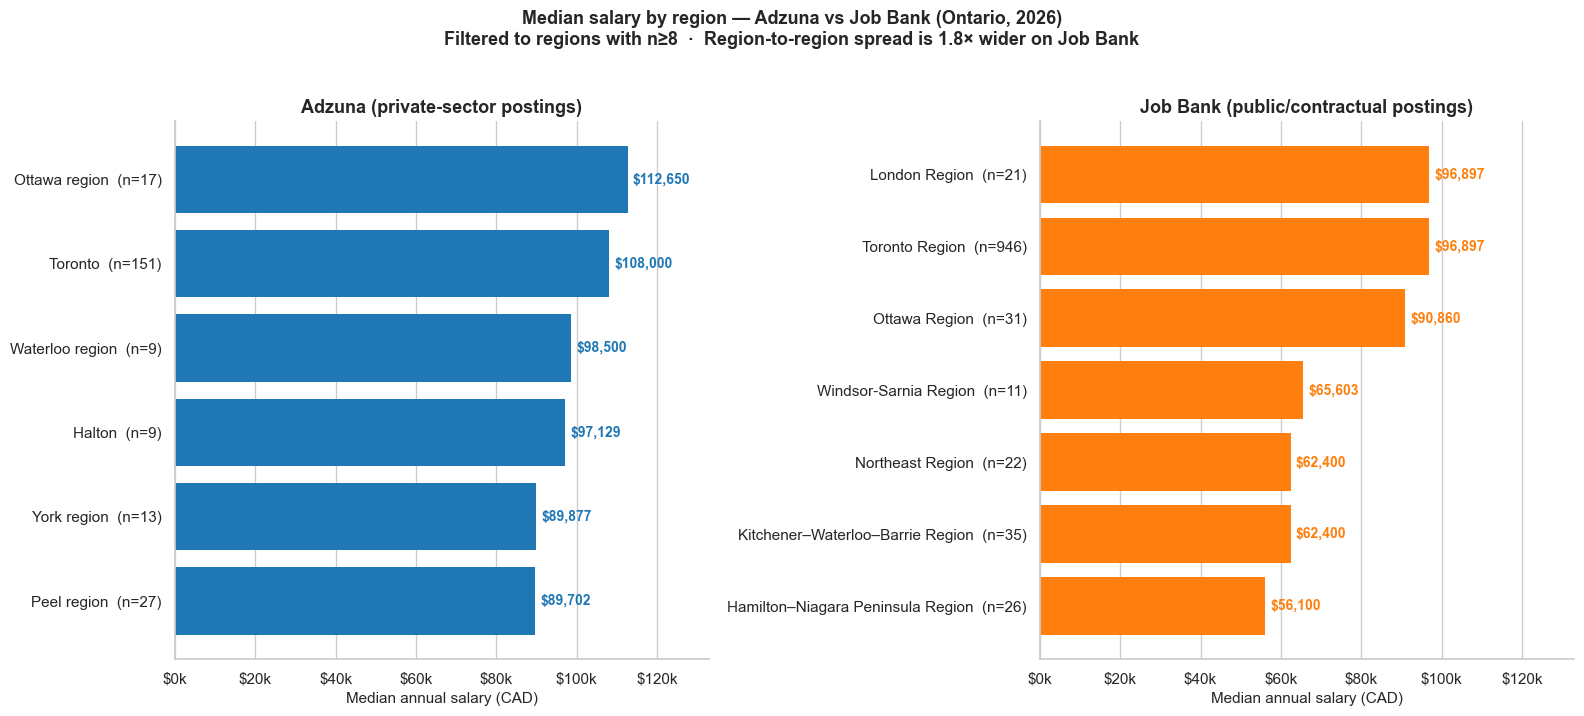

Saved → ..\outputs\figures\salary_by_region_barchart.png
   Spread Adzuna : $22,948  |  Spread Job Bank : $40,797  |  Ratio : 1.78×


In [31]:
# === Bar charts: median salary by region (filtered, n≥10, no fallback buckets) ===

# --- Filter thresholds ---
MIN_SAMPLE_REGION = 8
FALLBACK_BUCKETS = {'Unknown', 'Other Ontario'}

# --- Prep Adzuna ---
reg_adz = salary_region_adz[
    (salary_region_adz['count'] >= MIN_SAMPLE_REGION) &
    (~salary_region_adz['_city_bucket'].isin(FALLBACK_BUCKETS))
].sort_values('median', ascending=True).copy()
reg_adz['_label'] = reg_adz.apply(lambda r: f"{r['_city_bucket']}  (n={r['count']})", axis=1)

# --- Prep Job Bank ---
reg_jb = salary_region_jb[
    (salary_region_jb['count'] >= MIN_SAMPLE_REGION) &
    (~salary_region_jb['_region_bucket'].isin(FALLBACK_BUCKETS))
].sort_values('median', ascending=True).copy()
reg_jb['_label'] = reg_jb.apply(lambda r: f"{r['_region_bucket']}  (n={r['count']})", axis=1)

# --- Sanity check: report what was filtered out ---
dropped_adz = salary_region_adz[~salary_region_adz['_city_bucket'].isin(reg_adz['_city_bucket'])]
dropped_jb  = salary_region_jb[~salary_region_jb['_region_bucket'].isin(reg_jb['_region_bucket'])]
print(f'Adzuna : {len(reg_adz)} regions kept, {len(dropped_adz)} dropped')
print(f'   Dropped → {dropped_adz["_city_bucket"].tolist()}')
print(f'Job Bank : {len(reg_jb)} regions kept, {len(dropped_jb)} dropped')
print(f'   Dropped → {dropped_jb["_region_bucket"].tolist()}\n')

# --- Common X-axis (consistent with hero chart's spread story) ---
x_max = max(reg_adz['median'].max(), reg_jb['median'].max()) * 1.18

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True)

# Adzuna (left)
axes[0].barh(reg_adz['_label'], reg_adz['median'], color=ADZUNA_COLOR, edgecolor='none')
axes[0].set_title('Adzuna (private-sector postings)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Median annual salary (CAD)', fontsize=11)
axes[0].set_xlim(0, x_max)
for i, median in enumerate(reg_adz['median']):
    axes[0].text(median + x_max * 0.01, i, f'${median:,.0f}',
                 va='center', ha='left', fontsize=10, fontweight='bold', color=ADZUNA_COLOR)

# Job Bank (right)
axes[1].barh(reg_jb['_label'], reg_jb['median'], color=JOBBANK_COLOR, edgecolor='none')
axes[1].set_title('Job Bank (public/contractual postings)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Median annual salary (CAD)', fontsize=11)
axes[1].set_xlim(0, x_max)
for i, median in enumerate(reg_jb['median']):
    axes[1].text(median + x_max * 0.01, i, f'${median:,.0f}',
                 va='center', ha='left', fontsize=10, fontweight='bold', color=JOBBANK_COLOR)

# Formatting
for ax in axes:
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
    ax.grid(axis='y', visible=False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Compute ratio + auto-pick which source has wider spread
spread_adz = reg_adz['median'].max() - reg_adz['median'].min()
spread_jb  = reg_jb['median'].max()  - reg_jb['median'].min()

if spread_adz >= spread_jb:
    wider_source = 'Adzuna'
    ratio = spread_adz / spread_jb
else:
    wider_source = 'Job Bank'
    ratio = spread_jb / spread_adz

# ...puis dans le suptitle :
fig.suptitle(f'Median salary by region — Adzuna vs Job Bank (Ontario, 2026)\n'
             f'Filtered to regions with n≥{MIN_SAMPLE_REGION}  ·  '
             f'Region-to-region spread is {ratio:.1f}× wider on {wider_source}',
             fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'salary_by_region_barchart.png')
plt.show()

print(f'Saved → {FIGURES_DIR / "salary_by_region_barchart.png"}')
print(f'   Spread Adzuna : ${spread_adz:,.0f}  |  Spread Job Bank : ${spread_jb:,.0f}  |  Ratio : {ratio:.2f}×')

📊 Skills kept : 7  |  Total sample jobs (skills × salary) : 67
   Skills → ['Azure', 'SQL', 'Data Pipeline', 'Machine Learning', 'Dashboards', 'Reporting', 'Predictive Modeling']



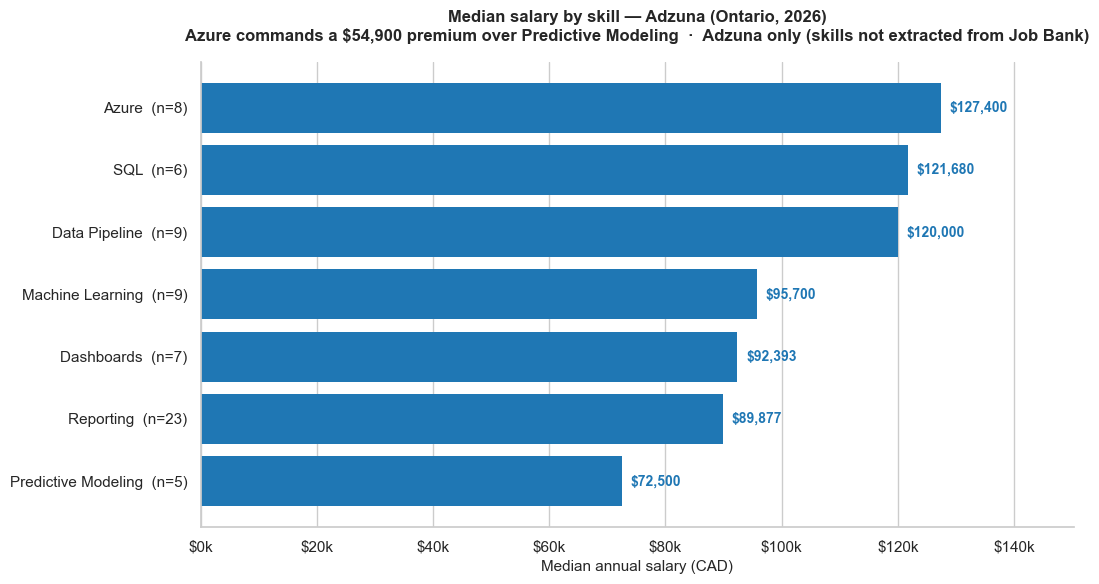

✅ Saved → ..\outputs\figures\salary_by_skill_barchart.png


In [35]:
# === Cell 6 — Bar chart: median salary by skill (Adzuna only) ===

# --- Filter threshold (consistent with Session 6: 7 publishable skills already filtered) ---
MIN_SAMPLE_SKILL = 5
sk = salary_skill_adz[salary_skill_adz['count'] >= MIN_SAMPLE_SKILL].copy()
sk = sk.sort_values('median', ascending=True)
sk['_label'] = sk.apply(lambda r: f"{r['_skills_list']}  (n={r['count']})", axis=1)

# Sanity check
print(f'📊 Skills kept : {len(sk)}  |  Total sample jobs (skills × salary) : {sk["count"].sum()}')
print(f'   Skills → {sk.sort_values("median", ascending=False)["_skills_list"].tolist()}\n')

# --- Plot ---
fig, ax = plt.subplots(figsize=(11, 6))

x_max = sk['median'].max() * 1.18

ax.barh(sk['_label'], sk['median'], color=ADZUNA_COLOR, edgecolor='none')

for i, median in enumerate(sk['median']):
    ax.text(median + x_max * 0.01, i, f'${median:,.0f}',
            va='center', ha='left', fontsize=10, fontweight='bold', color=ADZUNA_COLOR)

ax.set_xlim(0, x_max)
ax.set_xlabel('Median annual salary (CAD)', fontsize=11)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.grid(axis='y', visible=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Compute spread for subtitle
top_skill = sk.iloc[-1]
bottom_skill = sk.iloc[0]
premium = top_skill['median'] - bottom_skill['median']

ax.set_title(f'Median salary by skill — Adzuna (Ontario, 2026)\n'
             f'{top_skill["_skills_list"]} commands a ${premium:,.0f} premium over {bottom_skill["_skills_list"]}  ·  '
             f'Adzuna only (skills not extracted from Job Bank)',
             fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'salary_by_skill_barchart.png')
plt.show()

print(f'✅ Saved → {FIGURES_DIR / "salary_by_skill_barchart.png"}')

In [33]:
salary_skill_adz.columns.tolist()

['_skills_list', 'count', 'median', 'mean', 'min', 'max']